# Notebook 1) Mineral Identification

## Workflow

This notebook implements semantic segmentation of minerals in SEM (Scanning Electron Microscopy) images of lunar mare basalt samples. The workflow consists of the following steps:

### 1. Dataset Overview
- SEM BSE images and corresponding mineral labels from Apollo lunar samples
- Dataset Classes: 10 mineral classes for segmentation

### 2. Model Training and Evaluation
- **Architecture**: UNet-based models for semantic segmentation
  - **UNet_1**: Standard UNet architecture
  - **UNet_2**: Dual UNet with scale-based routing (small-scale vs large-scale)
  - **UNet_3**: UNet with continuous scale conditioning

- **Metrics**: Pixel accuracy and Intersection over Union (IoU)


### 3. Model Inference and Visualization
- Load saved pre-trained models and generate segmentation masks for new images
- Display input images, predictions, and ground truth labels



In [1]:
# Setup for Google Colab environment
# Note: This cell is specific to Google Colab. For local execution, modify paths accordingly.
from google.colab import drive
drive.mount('/content/drive')

FOLDERNAME = 'JGRML-mineral-identification-2025'
assert FOLDERNAME is not None, "[!] Enter the foldername."

import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
os.environ['TORCH_USE_CUDA_DSA'] = '1'

!cd /content/drive/MyDrive/$FOLDERNAME

Mounted at /content/drive


In [2]:
import csv
import glob
import random

import cv2
import numpy as np
from PIL import Image

import matplotlib.colors as mcolors
from matplotlib import pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import DataLoader, Dataset, Subset, random_split

from torchvision import datasets as tv_datasets
from torchvision import transforms as T

# -------------------------
# Local modules
# -------------------------
from utils.loadData import *
from utils.unet import *
from utils.metrics import *


In [3]:
USE_GPU = True
dtype = torch.float32 # We will be using float.

if USE_GPU and torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

# Constant to control how frequently we print train loss.
print_every = 100
print('using device:', device)

using device: cuda


# 1. Dataset Overview

## Data Collection and Preparation

We utilized various lunar mare basalt samples collected during the Apollo missions. The SEM Back Scattering Electron (BSE) images and corresponding wave dispersive data of the Apollo lunar samples were collected from the Stanford Mineral and Microchemical Analysis Facility.

### Data Processing Pipeline

1. **Image Acquisition**: SEM BSE images were collected with varying pixel scales (0.02-20 μm)
2. **Image Preprocessing**: Images were cropped to 256×256 pixels
3. **Manual Annotation**: Mineral segments were manually labeled based on electron microscopy results
4. **Pixel Scale Extraction**: Each image is associated with a pixel scale value stored in text files

### Dataset Structure

The dataset contains:
- **Input images**: 256×256 grayscale SEM images
- **Output masks**: 256×256 segmentation masks with 10 mineral classes
- **Pixel scale files**: Text files containing pixel size information for each image

In [5]:
# Extract the dataset zip file
# Note: Update the path to match your data location
import zipfile as zf

# Path to the dataset zip file
# For local execution, modify this path accordingly
################################################################################
files = zf.ZipFile(f"/content/drive/MyDrive/{FOLDERNAME}/data/data-sem-label.zip", 'r')
################################################################################

files.extractall()
files.close()

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [6]:
# Load dataset directories and define scale threshold
#
# Dataset organization:
# - Each sample folder contains:
#   1. input-features/: Text files with pixel scale information (in micrometers)
#   2. input-images/: 256×256 grayscale SEM input images
#   3. output-images/: 256×256 labeled segmentation masks
#
# The dataset includes samples from various Apollo missions with different rock types:
# - Ilmenite basalt
# - Olivine basalt
# - Pigeonite basalt

base_dir = 'data-sem-label'  # Root directory containing all data subfolders

# List all "input-features" directories (contain pixel scale text files)
input_features_folders = sorted([
    path for path in glob.glob(os.path.join(base_dir, '*', 'input-features'))
    if '.ipynb_checkpoints' not in path
])

# List all "input-images" directories (256 × 256 grayscale SEM input images)
input_image_folders = sorted([
    path for path in glob.glob(os.path.join(base_dir, '*', 'input-images'))
    if '.ipynb_checkpoints' not in path
])

# List all "output-images" directories (256 × 256 labeled segmentation masks)
output_image_folders = sorted([
    path for path in glob.glob(os.path.join(base_dir, '*', 'output-images'))
    if '.ipynb_checkpoints' not in path
])

# Define a scale threshold (in micrometers) to separate small-scale vs large-scale datasets
# This threshold is used for UNet_2 model which routes samples based on pixel scale
scale_criteria = 1.8  # micrometer

print(f"Found {len(input_image_folders)} sample folders")
print(f"Scale threshold: {scale_criteria} μm")

Found 28 sample folders
Scale threshold: 1.8 μm


## 1-1. Pixel Scale Variability

### Challenge of Scale in Microscopic Images

Most computer vision implementations for microscopic scale images do not adequately consider the physical scales of the collected images. Typically, each SEM image (or other microscopic images such as CT scans) is given a unique scale, with pixel sizes ranging approximately between 0.01 μm and 10 μm.

### Impact of Scale Variability

This scale variability leads to different patterns or mineral occurrences within the same sample. For example:
- **Large pixel sizes (>1.8 μm)**
- **Small pixel sizes (≤1.8 μm)**

### Our Approach

Here, we have collected SEM images with a scalar input representing the pixel scale for each image, which varies between 0.02 μm and 20 μm. This scale information is crucial for our models:

- **UNet_1**: Baseline model that ignores scale information
- **UNet_2**: Dual UNet that routes samples based on a 1.8 μm threshold
- **UNet_3**: Continuous scale conditioning that incorporates scale at the bottleneck layer

For the discrete method (UNet_2), we separate our dataset based on the 1.8 μm cutoff to train separate models for large-scale and small-scale images.





Total images with pixel size information: 16080

Example pixel sizes:
  10003_site3_2-1-1_b75: 6.5104 μm
  10003_site4_metal1_3-3_b75: 0.5208 μm
  10003_site1_metal1_4-1_b110: 0.2222 μm
  10003_site2_19-4_b100: 2.3810 μm
  10003_location_8-3_b75: 2.3810 μm
  10003_site2_1-1_b100: 2.3810 μm
  10003_Sem_BED-C_001_4-1_b75: 0.3196 μm


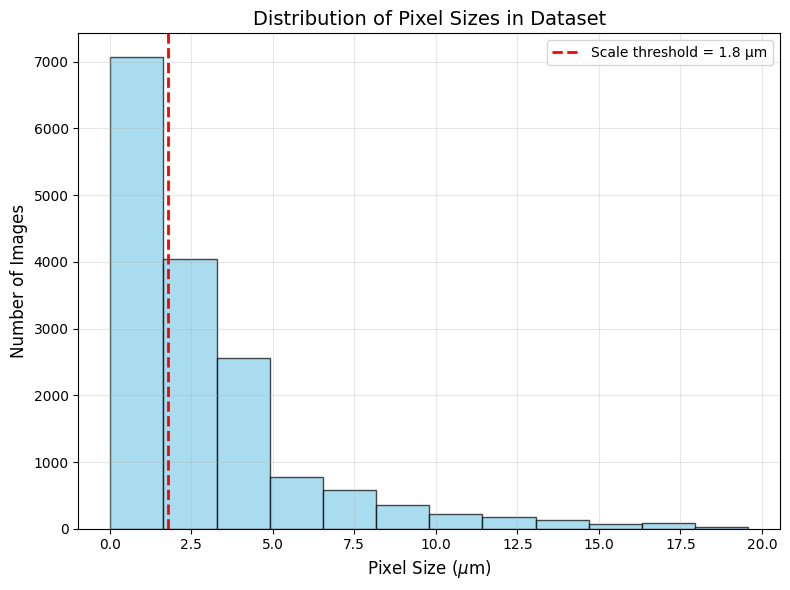


Pixel size range:
  Minimum: 0.020 μm
  Maximum: 19.575 μm
  Range: 19.555 μm


In [7]:
# Extract pixel size information from text files
# Each text file contains a line with format: "pixel_size: <value>"
pixel_size_dict = {}

# Loop through all input-feature folders
for input_features_folder in input_features_folders:
    # Iterate through each file in the current folder
    for filename in os.listdir(input_features_folder):
        # Only process text files that contain pixel size information
        if filename.endswith(".txt"):
            base_name = filename.split('.txt')[0]  # Remove file extension to get base name
            # Extract pixel size value from the text file
            pixel_size = get_pixel_size(os.path.join(input_features_folder, filename))
            # Store valid pixel size values in the dictionary
            if pixel_size is not None:
                pixel_size_dict[base_name] = pixel_size

# Print dataset summary
print(f'Total images with pixel size information: {len(pixel_size_dict)}')
print('\nExample pixel sizes:')
# Show the first few entries as examples
for key, value in list(pixel_size_dict.items())[:7]:
    print(f'  {key}: {value:.4f} μm')

# Visualize the pixel size distribution
num_bins = 12  # Number of histogram bins

# Sort the pixel sizes for visualization
pixel_sizes = sorted(pixel_size_dict.values())

# Create histogram of pixel size distribution
plt.figure(figsize=(8, 6))
plt.hist(pixel_sizes, bins=num_bins, color='skyblue', edgecolor='black', alpha=0.7)

# Add a red dashed vertical line to indicate the scale_criteria threshold
plt.axvline(scale_criteria, color='red', linestyle='--', linewidth=2,
            label=f'Scale threshold = {scale_criteria} μm')

# Label axes and add a title
plt.xlabel(r'Pixel Size ($\mu$m)', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.title('Distribution of Pixel Sizes in Dataset', fontsize=14)

# Add legend, grid, and improve layout
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print min and max pixel sizes
min_scale = float(np.min(pixel_sizes))
max_scale = float(np.max(pixel_sizes))
print(f"\nPixel size range:")
print(f"  Minimum: {min_scale:.3f} μm")
print(f"  Maximum: {max_scale:.3f} μm")
print(f"  Range: {max_scale - min_scale:.3f} μm")

In [8]:
# Organize dataset into whole, large-scale, and small-scale subsets
# This organization is used for training different model variants

import os

# Initialize lists for dataset organization
input_whole_pixel, output_whole_pixel, filenames_whole_pixel = [], [], []
input_large_pixel, output_large_pixel, filenames_large_pixel = [], [], []
input_small_pixel, output_small_pixel, filenames_small_pixel = [], [], []

# Extract base name from filename (safe extension/key extraction)
def img_key(name):
    """Extract base name from filename without extension."""
    return os.path.splitext(name)[0]  # 'xxx.png' -> 'xxx'

# Organize images into whole dataset and scale-based subsets
for in_dir, out_dir in zip(input_image_folders, output_image_folders):
    for image_name in os.listdir(in_dir):
        if not image_name.lower().endswith(".png"):
            continue

        key = img_key(image_name)  # Use same key format as pixel_size_dict
        if key not in pixel_size_dict:
            continue

        in_path = os.path.join(in_dir, image_name)
        out_path = os.path.join(out_dir, image_name)

        # Add to whole dataset
        input_whole_pixel.append(in_path)
        output_whole_pixel.append(out_path)
        filenames_whole_pixel.append(image_name)

        # Split into large/small based on scale threshold
        if pixel_size_dict[key] > scale_criteria:
            input_large_pixel.append(in_path)
            output_large_pixel.append(out_path)
            filenames_large_pixel.append(image_name)
        else:
            input_small_pixel.append(in_path)
            output_small_pixel.append(out_path)
            filenames_small_pixel.append(image_name)

# Create PyTorch datasets
# Each dataset returns: (input_image, output_mask, pixel_size, filename)
datasets_whole_pixel = create_segmentation_dataset(
    input_whole_pixel, output_whole_pixel, pixel_size_dict, filenames_whole_pixel
)
datasets_large_pixel = create_segmentation_dataset(
    input_large_pixel, output_large_pixel, pixel_size_dict, filenames_large_pixel
)
datasets_small_pixel = create_segmentation_dataset(
    input_small_pixel, output_small_pixel, pixel_size_dict, filenames_small_pixel
)

# Print dataset sizes
print("Dataset sizes:")
print(f"  Whole dataset: {len(datasets_whole_pixel)} images")
print(f"  Large-scale (> {scale_criteria} μm): {len(datasets_large_pixel)} images")
print(f"  Small-scale (≤ {scale_criteria} μm): {len(datasets_small_pixel)} images")

# Verify dataset structure by examining a sample
sample = datasets_large_pixel[0]

if len(sample) == 4:
    input_image, output_image, pixel_size_tensor, filename = sample
elif len(sample) == 5:
    input_image, output_image, pixel_size_tensor, label_tensor, filename = sample
else:
    raise RuntimeError(f"Unexpected dataset item length: {len(sample)}")

# Extract pixel size value from tensor
pixel_size = float(pixel_size_tensor.item() if hasattr(pixel_size_tensor, "item") else pixel_size_tensor)

print(f"\nSample verification (large-scale dataset):")
print(f"  Input image shape: {input_image.shape}")
print(f"  Output mask shape: {output_image.shape}")
print(f"  Pixel size: {pixel_size:.3f} μm")
print(f"  Filename: {filename}")



Dataset sizes:
  Whole dataset: 16064 images
  Large-scale (> 1.8 μm): 8624 images
  Small-scale (≤ 1.8 μm): 7440 images

Sample verification (large-scale dataset):
  Input image shape: torch.Size([1, 256, 256])
  Output mask shape: torch.Size([1, 256, 256])
  Pixel size: 2.381 μm
  Filename: 10003_site1_5-2_b75.png


## 1-2. Dataset Structure and Classes

### Input Format

Each image in the dataset consists of three components:

1. **Pixel matrix**: 256×256 grayscale SEM image
2. **Single channel**: Intensity map representing backscattered electron signal
3. **Pixel scale**: Scalar value representing the pixel size in micrometers (ranges from 0.02 μm to 20 μm)

### Output Format

The output labels are 256×256 segmentation masks where each pixel is assigned to one of 10 mineral classes. The class vector is defined as $y \in (c_0, c_1, c_2, \ldots, c_9)$, where each $c_i$ represents a distinct mineral class:

- **$c_0$: Void** - Empty spaces, cracks, or artifacts
- **$c_1$: Metallic Fe** - Iron-nickel alloys including Kamacite and Martensite
- **$c_2$: FeS (Troilite)** - Iron sulfide
- **$c_3$: Metal oxides** - Ilmenite, Ulvospinel, Chromite
- **$c_4$: Pyroxene group** - Augite, Pigeonite, Clinopyroxene, Orthopyroxene
- **$c_5$: Plagioclase** - Feldspar minerals
- **$c_6$: Silicate minerals** - Quartz, Cristobalite, or Glass
- **$c_7$: Olivine** - Olivine group minerals
- **$c_8$: Late-stage melt compositions** - Mesostasis, Groundmass
- **$c_9$: Other** - Rare phases such as Phosphate, Zircon, or other minerals not in the above categories

### Data Augmentation

The square images were augmented by performing three 90-degree rotations and adjusting the brightness. These alterations simulate common variations that occur during SEM sample loadings, thereby providing meaningful data augmentation for training robust models.


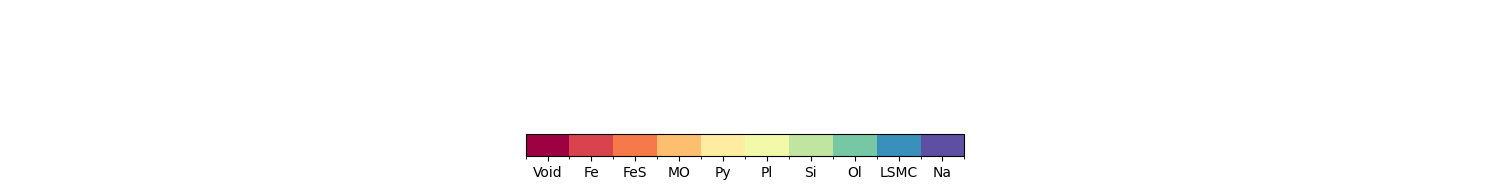

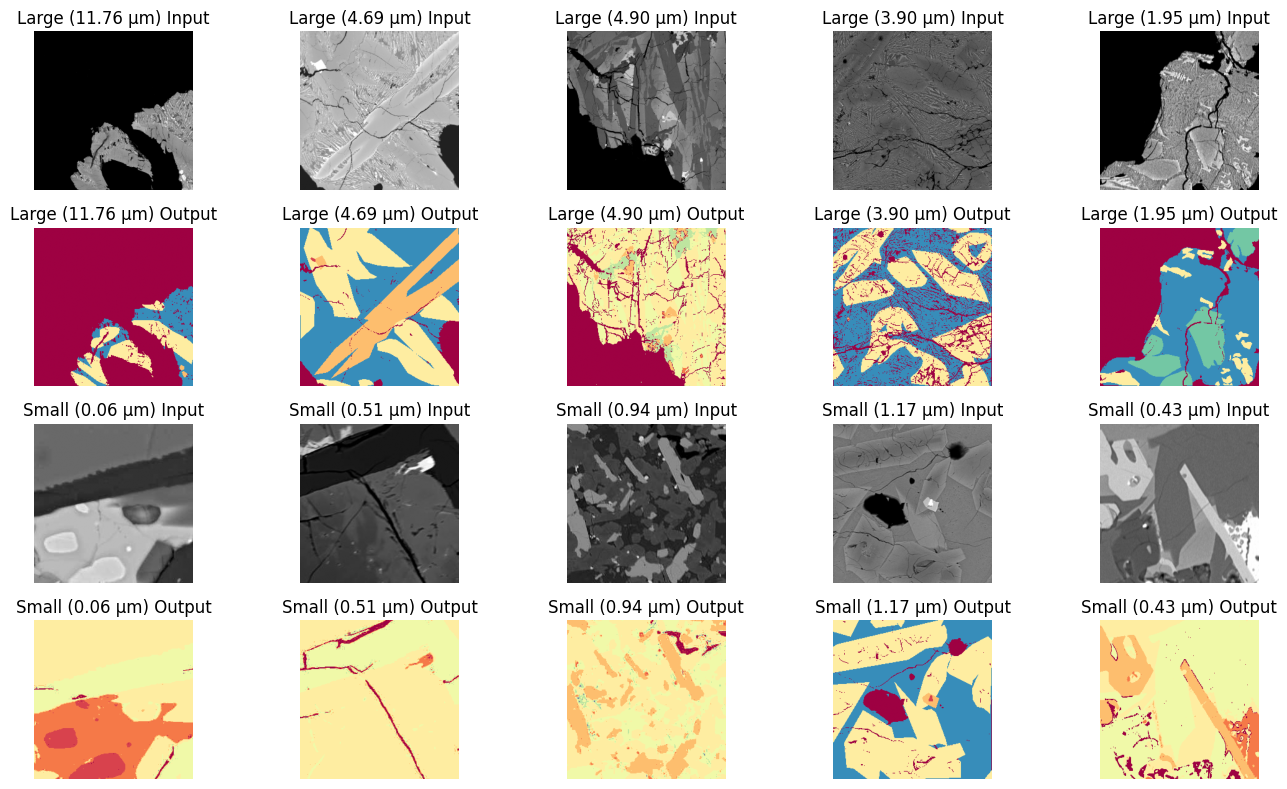

In [10]:

################################################################################
""" Number of random samples to display (modify if you want) """

num_samples = 5

################################################################################


# Define the bounds and their respective labels
import matplotlib.colors as colors

class_labels = ["Void", "Fe", "FeS", "MO", "Py", "Pl", "Si", "Ol", "LSMC", "Na"]
n_classes = len(class_labels)
bounds = np.arange(0, n_classes + 1)

# Create a colormap
cmap = plt.cm.Spectral
norm = colors.BoundaryNorm(boundaries=bounds, ncolors=cmap.N)

# Plotting
fig, ax = plt.subplots(figsize=(15, 2))
colorbar = plt.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    ax=ax,
    ticks=np.arange(n_classes) + 0.5,
    orientation="horizontal",
    spacing="proportional"
)

colorbar.set_ticklabels(class_labels)
ax.axis("off")

plt.tight_layout()
plt.show()

def plot_dataset_sample(input_image, output_image, row, col_offset, title_prefix, sample_num, num_samples):
    """
    Plot and visualize the dataset samples.
    """
    # Convert PyTorch tensors to numpy arrays
    input_image_np = input_image.numpy()
    output_image_np = output_image.numpy()

    # Convert from [C, H, W] format to [H, W, C] format
    input_image_np = np.squeeze(np.transpose(input_image_np, (1, 2, 0)))
    output_image_np = np.squeeze(np.transpose(output_image_np, (1, 2, 0)))

    # Plot the images
    plt.subplot(4, num_samples, num_samples * (row-1) + col_offset + 1)
    plt.imshow(input_image_np, cmap='gray')
    plt.title(f'{title_prefix} Input')
    plt.axis('off')

    plt.subplot(4, num_samples, num_samples * row + col_offset + 1)
    plt.imshow(output_image_np, cmap=cmap, vmin=0, vmax=9)
    plt.title(f'{title_prefix} Output')
    plt.axis('off')


plt.figure(figsize=(14, 8))

for i in range(num_samples):
    # large
    random_idx = random.randint(0, len(datasets_large_pixel) - 1)
    input_image_large, output_image_large, pixel_size_large, fname_large = datasets_large_pixel[random_idx]
    plot_dataset_sample(input_image_large, output_image_large, 1, i,
                        f"Large ({pixel_size_large:.2f} μm)", i+1, num_samples)

    # small
    random_idx = random.randint(0, len(datasets_small_pixel) - 1)
    input_image_small, output_image_small, pixel_size_small, fname_small = datasets_small_pixel[random_idx]
    plot_dataset_sample(input_image_small, output_image_small, 3, i,
                        f"Small ({pixel_size_small:.2f} μm)", i+1, num_samples)

plt.tight_layout()
plt.show()

# 2. Model Training

## Architecture Overview

We employed the U-Net architecture, a convolutional neural network (CNN) specifically designed for image segmentation tasks, as the backbone to segment minerals from SEM images. The U-Net architecture consists of an encoder-decoder structure with skip connections, which is well-suited for pixel-level classification tasks.

## Model Variants

This notebook demonstrates training of **UNet_1**, the baseline model that does not use scale information. The code can be easily modified to train other variants:

- **UNet_1**: Standard U-Net without scale conditioning (shown in this example)
- **UNet_2**: Dual U-Net with routing based on pixel scale threshold
- **UNet_3**: U-Net with continuous scale conditioning at bottleneck

## Training Configuration

Using the PyTorch library, you can train models on different dataset sizes (e.g., 192, 384, 800, 1,600, 3,200, 6,400, and 12,800 samples) to evaluate the effect of training data size on model performance. The example below shows training of UNet_1 model.



In [11]:
# Training script for UNet segmentation model
# This cell implements the complete training pipeline with proper data splitting

import os
import csv
import random
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
from collections import defaultdict
from torch.utils.data import Subset, DataLoader

# --------------------------
# Helper functions for data splitting
# --------------------------

def group_indices_by_prefix(filenames):
    """
    Group indices by filename prefix to prevent data leakage.

    Images from the same sample (same prefix) are kept together to ensure
    that training and validation sets don't contain related images.
    """
    groups = defaultdict(list)
    for i, name in enumerate(filenames):
        p = name.split('-')[0]  # Extract prefix before first hyphen
        groups[p].append(i)
    return [g for g in groups.values() if g]


def sample_groups(groups, target, seed=42):
    """
    Sample groups to approach target size.

    This function samples entire groups (not individual images) to maintain
    the integrity of related images and prevent data leakage.
    """
    rnd = random.Random(seed)
    order = list(range(len(groups)))
    rnd.shuffle(order)
    picked, total = [], 0
    for gi in order:
        g = groups[gi]
        if total + len(g) <= target:
            picked.extend(g)
            total += len(g)
        if total >= target:
            break
    return picked, total


def filter_groups_excluding(groups, exclude_set):
    """
    Remove indices in exclude_set, keep only non-empty groups.

    Used to create training groups that exclude validation samples.
    """
    out = []
    for g in groups:
        gg = [i for i in g if i not in exclude_set]
        if gg:
            out.append(gg)
    return out

# =========================
# 1) Training Configuration
# =========================
# Dataset size: Can be varied to study the effect of training data size
TARGET_N = 800  # Options: 800, 1600, 3200, 6400, 12800

# Training hyperparameters
BATCH_SIZE = 10
SEED_VAL = 42      # Fixed seed for validation split (ensures reproducibility)
SEED_TRAIN = 42    # Seed for training subset sampling
NUM_WORKERS = 0    # Number of data loading workers (0 for Colab)
PIN_MEMORY = False

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Model configuration
in_channels = 1      # Grayscale input
out_channels = 10    # Number of mineral classes
num_classes = out_channels

# Training parameters
num_epochs = 10      # Number of training epochs (increase for full training)
learning_rate = 1e-4
weight_decay = 1e-5
step_size = 50       # Learning rate scheduler step size
gamma = 0.1          # Learning rate decay factor
MODEL_TAG = "m1"     # Model identifier (m1=UNet_1, m2=UNet_2, m3=UNet_3)

# =========================
# 2) Validation Split
# =========================
# Create validation set: 1024 samples each from large and small scale datasets
# This ensures balanced validation across different scales
N_large = len(filenames_large_pixel)

large_groups_all = group_indices_by_prefix(filenames_large_pixel)
small_groups_all = group_indices_by_prefix(filenames_small_pixel)

val_idx_large, nL = sample_groups(large_groups_all, 1024, seed=SEED_VAL)
val_idx_small, nS = sample_groups(small_groups_all, 1024, seed=SEED_VAL)
print(f"[VAL] large={nL}, small={nS}, total={nL+nS}")

# Convert to full dataset indices (small indices offset by N_large)
val_indices = val_idx_large + [i + N_large for i in val_idx_small]

# =========================
# 3) Training Pool
# =========================
# Create training pool by excluding validation samples
# This prevents data leakage between training and validation sets
all_idx_large = set(range(len(filenames_large_pixel)))
all_idx_small = set(range(len(filenames_small_pixel)))
val_set_large = set(val_idx_large)
val_set_small = set(val_idx_small)

pool_large = sorted(all_idx_large - val_set_large)
pool_small = sorted(all_idx_small - val_set_small)

# Create groups from training pool only (validation samples excluded)
train_groups_large = filter_groups_excluding(
    group_indices_by_prefix(filenames_large_pixel), val_set_large
)
train_groups_small = filter_groups_excluding(
    group_indices_by_prefix(filenames_small_pixel), val_set_small
)

# =========================
# 4) Balanced Training Subset
# =========================
# Sample balanced training set: half from large-scale, half from small-scale
# This ensures the model sees both types of images during training
half_target = TARGET_N // 2
train_idx_l, n_l = sample_groups(train_groups_large, half_target, seed=SEED_TRAIN)
train_idx_s, n_s = sample_groups(train_groups_small, half_target, seed=SEED_TRAIN)
train_idx_balanced = train_idx_l + [i + N_large for i in train_idx_s]

# Safety check: ensure no overlap between train and validation
assert set(train_idx_balanced).isdisjoint(set(val_indices)), "Data leakage detected: train ∩ val ≠ ∅"

# =========================
# 5) Create Data Loaders
# =========================
# Combine large and small scale datasets into a single dataset
combined_inputs = input_large_pixel + input_small_pixel
combined_outputs = output_large_pixel + output_small_pixel
combined_names = filenames_large_pixel + filenames_small_pixel

# Create PyTorch dataset
datasets_whole_pixel = create_segmentation_dataset(
    combined_inputs, combined_outputs, pixel_size_dict, combined_names
)

# Create training and validation subsets
train_subset = Subset(datasets_whole_pixel, train_idx_balanced)
val_subset = Subset(datasets_whole_pixel, val_indices)

# Create data loaders
loader_train = DataLoader(
    train_subset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)
loader_val = DataLoader(
    val_subset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)

print(f"[RUN] target={TARGET_N} → actual={len(train_subset)} "
      f"({len(train_idx_l)} large + {len(train_idx_s)} small), val={len(val_subset)}")

# =========================
# 6) Initialize Model, Optimizer, and Logging
# =========================
# Initialize UNet_1 model (baseline without scale conditioning)
model = UNet_1(in_channels, out_channels).to(device)

# Loss function: Cross-entropy for multi-class segmentation
criterion = nn.CrossEntropyLoss()

# Optimizer: Adam with weight decay for regularization
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)

# Learning rate scheduler: Step decay every 'step_size' epochs
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=step_size, gamma=gamma
)

# Setup directories for saving models and logs
# Note: Update these paths for your environment
LOG_DIR = Path("/content/drive/MyDrive/XXXXXXXX")  # Update with your log directory
MODEL_DIR = Path("/content/drive/MyDrive/XXXXXXXX")  # Update with your model directory
LOG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

csv_path = LOG_DIR / f"Test-{MODEL_TAG}_subset_{TARGET_N}.csv"
best_path = MODEL_DIR / f"Test-{MODEL_TAG}-best-{TARGET_N}.pth"

hyperparameters = {
    "num_epochs": num_epochs,
    "learning_rate": learning_rate,
    "weight_decay": weight_decay,
    "batch_size": BATCH_SIZE,
    "step_size": step_size,
    "gamma": gamma,
    "TARGET_N": TARGET_N,
    "model_tag": MODEL_TAG,
    "min_scale": float(min_scale),
    "max_scale": float(max_scale),
}

# CSV header (only if file doesn't exist)
if not csv_path.exists():
    with open(csv_path, "w", newline="") as f:
        header = ["epoch","train_loss","val_loss","train_accuracy","val_accuracy"] + \
                 [f"train_iou_class_{i}" for i in range(num_classes)] + \
                 [f"val_iou_class_{i}" for i in range(num_classes)] + \
                 list(hyperparameters.keys()) + ["target_n","actual_n"]
        csv.writer(f).writerow(header)

# =========================
# 7) Training Loop
# =========================
best_val_accuracy = 0.0

for epoch in range(num_epochs):
    # ---- Training Phase ----
    model.train()
    correct_train = 0
    total_train_pixels = 0
    ious_sum_train = np.zeros(num_classes, dtype=np.float64)
    # Weighted average loss over all pixels (not batch average)
    train_loss_sum = 0.0

    for batch in loader_train:
        # Flexible unpacking (handles 3-tuple/4-tuple)
        if len(batch) == 4:
            input_images, output_images, pixel_size, _ = batch
        elif len(batch) == 3:
            input_images, output_images, pixel_size = batch
        else:
            input_images, output_images = batch
            pixel_size = None

        input_images = input_images.to(device)
        output_images = output_images.to(device).long().squeeze(1)  # [B,H,W]

        # Forward pass
        optimizer.zero_grad()
        predictions = model(input_images)  # [B,C,H,W]
        loss = criterion(predictions, output_images)  # Mean over pixels of the batch
        loss.backward()
        optimizer.step()

        # Compute metrics (pixel-wise)
        _, predicted = torch.max(predictions.data, 1)  # [B,H,W]
        batch_pixels = output_images.numel()

        # Weighted sum: (batch average loss * pixel count)
        # This ensures correct averaging when batch sizes vary
        train_loss_sum += loss.item() * batch_pixels
        correct_train += (predicted == output_images).sum().item()
        ious_sum_train += np.array(compute_iou(predicted, output_images, num_classes))
        total_train_pixels += batch_pixels

    # ---- Validation Phase ----
    model.eval()
    correct_val = 0
    total_val_pixels = 0
    ious_sum_val = np.zeros(num_classes, dtype=np.float64)
    val_loss_sum = 0.0

    with torch.no_grad():
        for batch in loader_val:
            if len(batch) == 4:
                input_images, output_images, pixel_size, _ = batch
            elif len(batch) == 3:
                input_images, output_images, pixel_size = batch
            else:
                input_images, output_images = batch
                pixel_size = None

            input_images = input_images.to(device)
            output_images = output_images.to(device).long().squeeze(1)

            predictions = model(input_images)
            loss = criterion(predictions, output_images)

            _, predicted = torch.max(predictions.data, 1)
            batch_pixels = output_images.numel()

            val_loss_sum += loss.item() * batch_pixels
            correct_val += (predicted == output_images).sum().item()
            ious_sum_val += np.array(compute_iou(predicted, output_images, num_classes))
            total_val_pixels += batch_pixels

    # ---- Compute Epoch Metrics ----
    # Pixel-weighted averages ensure correct metrics regardless of batch size
    train_loss = train_loss_sum / max(1, total_train_pixels)
    val_loss = val_loss_sum / max(1, total_val_pixels)
    train_acc = correct_train / max(1, total_train_pixels)
    val_acc = correct_val / max(1, total_val_pixels)
    train_iou = (ious_sum_train / max(1, len(loader_train))).tolist()
    val_iou = (ious_sum_val / max(1, len(loader_val))).tolist()

    print(f"[{TARGET_N}] Epoch {epoch+1:03d}/{num_epochs} "
          f"| train {train_loss:.4f}/{train_acc:.4f} "
          f"| val {val_loss:.4f}/{val_acc:.4f}")

    # Save best model based on validation accuracy
    if val_acc > best_val_accuracy and epoch > 1:
        best_val_accuracy = val_acc
        torch.save(model.state_dict(), best_path)
        print(f"[CKPT] saved best model → {best_path}")

    scheduler.step()

    # ---- Log to CSV ----
    with open(csv_path, "a", newline="") as f:
        row = ([epoch + 1, train_loss, val_loss, train_acc, val_acc] +
               train_iou + val_iou +
               [hyperparameters[k] for k in hyperparameters.keys()] +
               [TARGET_N, n_l + n_s])
        csv.writer(f).writerow(row)

print(f"\n[FINAL] Training completed")
print(f"  Target samples: {TARGET_N}")
print(f"  Actual samples: {n_l + n_s} ({n_l} large + {n_s} small)")
print(f"  Validation samples: {len(val_subset)}")
print(f"  Best validation accuracy: {best_val_accuracy:.4f}")
print(f"\nSaved files:")
print(f"  Model: {best_path}")
print(f"  Log: {csv_path}")

Using device: cuda
[VAL] large=1024, small=1024, total=2048
[RUN] target=800 → actual=800 (400 large + 400 small), val=2048
[800] Epoch 001/10 | train 1.9290/0.4125 | val 1.7379/0.5169
[800] Epoch 002/10 | train 1.6800/0.5202 | val 1.6578/0.5057
[800] Epoch 003/10 | train 1.5672/0.5402 | val 1.5953/0.5284
[CKPT] saved best model → /content/drive/MyDrive/XXXXXXXX/Test-m1-best-800.pth
[800] Epoch 004/10 | train 1.5093/0.5379 | val 1.5081/0.5306
[CKPT] saved best model → /content/drive/MyDrive/XXXXXXXX/Test-m1-best-800.pth
[800] Epoch 005/10 | train 1.4670/0.5447 | val 1.4500/0.5225
[800] Epoch 006/10 | train 1.4217/0.5508 | val 1.4252/0.5384
[CKPT] saved best model → /content/drive/MyDrive/XXXXXXXX/Test-m1-best-800.pth
[800] Epoch 007/10 | train 1.3775/0.5619 | val 1.3801/0.5627
[CKPT] saved best model → /content/drive/MyDrive/XXXXXXXX/Test-m1-best-800.pth
[800] Epoch 008/10 | train 1.3423/0.5743 | val 1.3766/0.5402
[800] Epoch 009/10 | train 1.3162/0.5734 | val 1.3485/0.5686
[CKPT] save

# 3. Model Inference and Visualization

## Loading Pre-trained Models

This section demonstrates how to load a pre-trained model and use it for inference on new images. This is useful for:
- **Model evaluation**: Testing model performance on validation or test sets
- **Visual inspection**: Verifying that the model produces reasonable segmentation results
- **Qualitative analysis**: Comparing predictions with ground truth masks


This allows for quick visual assessment of model performance and identification of common failure modes.

In [14]:
# Load a pre-trained model for inference
# Note: Update the model path to point to your trained model

in_channels = 1   # Grayscale images
out_channels = 10 # Number of mineral classes
num_classes = out_channels

# Initialize model with same architecture as training
model = UNet_1(in_channels, out_channels).to(device)

# Load trained weights
# Note: Update this path to your saved model checkpoint
model_path = '/content/drive/MyDrive/JGRML-mineral-identification-2025/models/Unets/m1-best-12800.pth'
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()  # Set to evaluation mode

print(f"Model loaded from: {model_path}")
print("Model set to evaluation mode.")

Model loaded from: /content/drive/MyDrive/JGRML-mineral-identification-2025/models/Unets/m1-best-12800.pth
Model set to evaluation mode.


In [15]:
# Visualization utilities for model inference

import os
import cv2
import math
import torch
import matplotlib.pyplot as plt
from PIL import Image

def round_to_sf(number, sf):
    """
    Round number to specified significant figures.

    Args:
        number: Number to round
        sf: Number of significant figures

    Returns:
        Rounded number
    """
    if number == 0:
        return 0
    else:
        return round(number, -int(math.floor(math.log10(abs(number))) - (sf - 1)))


def display_single_sample(input_image_path, transform, model, pixel_size_dict, norm, cmap):
    """
    Display input image, ground truth (if available), and model prediction.

    This function provides a side-by-side comparison of:
    1. Input SEM image
    2. Ground truth segmentation mask (if available)
    3. Model prediction

    Args:
        input_image_path: Path to input SEM image
        transform: Image transformation pipeline
        model: Trained segmentation model
        pixel_size_dict: Dictionary mapping image names to pixel sizes
        norm: Normalization for colormap
        cmap: Colormap for visualization

    Returns:
        Predicted segmentation map as numpy array
    """
    plt.figure(figsize=(15, 4))

    # Load the image and pixel size
    img = cv2.imread(input_image_path)
    input_image = Image.open(input_image_path)
    transformed_input = transform(input_image).unsqueeze(0).to(device)

    base_name = os.path.basename(input_image_path).split('.')[0]

    if base_name not in pixel_size_dict:
        print(f"Warning: No pixel size information for {base_name}")
        pixel_size = 0.0
    else:
        pixel_size = pixel_size_dict[base_name]

    # Display input image
    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Input Image\nPixel Size: {round_to_sf(pixel_size, 3)} μm/px", fontsize=11)
    plt.axis('off')

    # Model prediction
    with torch.no_grad():
        prediction = model(transformed_input)

    _, predicted_class_map = prediction.max(dim=1)
    predicted_class_map_np = predicted_class_map.squeeze().cpu().numpy()

    # Display ground truth if it exists
    output_image_path = input_image_path.replace("input-images", "output-images")
    if os.path.exists(output_image_path):
        ground_truth_img = cv2.imread(output_image_path, cv2.IMREAD_GRAYSCALE)
        plt.subplot(1, 3, 2)
        plt.imshow(ground_truth_img, norm=norm, cmap=cmap)
        plt.title("Ground Truth", fontsize=11)
        plt.axis('off')
    else:
        plt.subplot(1, 3, 2)
        plt.text(0.5, 0.5, "Ground truth\nnot available",
                ha='center', va='center', fontsize=12)
        plt.axis('off')

    # Display prediction
    plt.subplot(1, 3, 3)
    plt.imshow(predicted_class_map_np, norm=norm, cmap=cmap)
    plt.title("Model Prediction", fontsize=11)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    return predicted_class_map_np


Visualizing prediction for: 15016_43-4_b50.png


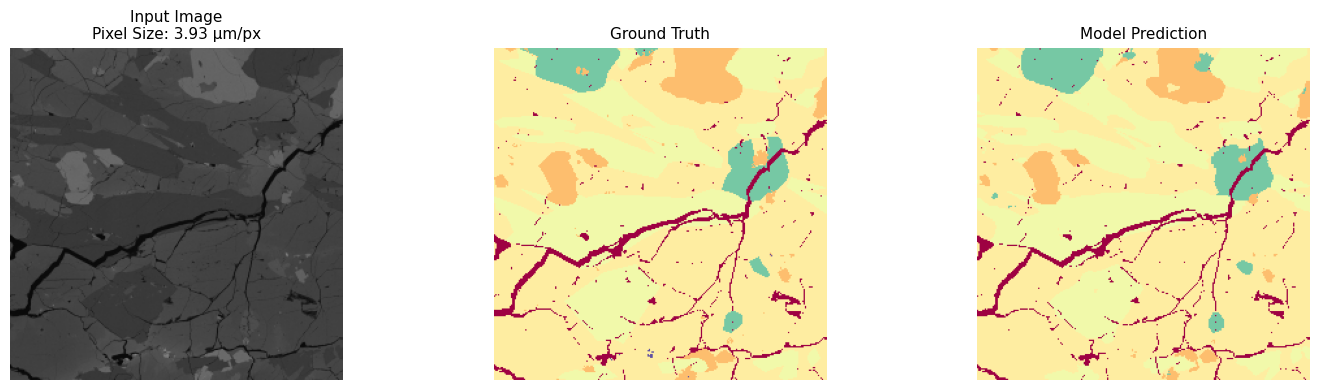

In [16]:
# Visualize model predictions on random samples
# This helps verify that the trained model produces reasonable segmentations

import random
from torchvision import transforms
import matplotlib.colors as colors

# Image transformation pipeline (must match training preprocessing)
transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.ToTensor(),
])

# Setup colormap for visualization (must match earlier definition)
class_labels = ["Void", "Fe", "FeS", "MO", "Py", "Pl", "Si", "Ol", "LSMC", "Na"]
n_classes = len(class_labels)
bounds = np.arange(0, n_classes + 1)
cmap = plt.cm.Spectral
norm = colors.BoundaryNorm(boundaries=bounds, ncolors=cmap.N)

# Randomly pick one image path from the large-scale dataset
sample_image = random.choice(input_large_pixel)

print(f"Visualizing prediction for: {os.path.basename(sample_image)}")
print("=" * 60)

# Display result for that sample
predicted_map = display_single_sample(
    sample_image, transform, model, pixel_size_dict, norm, cmap
)